##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
!pip install --upgrade keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 38.0 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Loading YOLOv8 Model (Pascal VOC Preset)...
163759/163759 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
141886/141886 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
133495/133495 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
113880/113880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
487438/487438 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


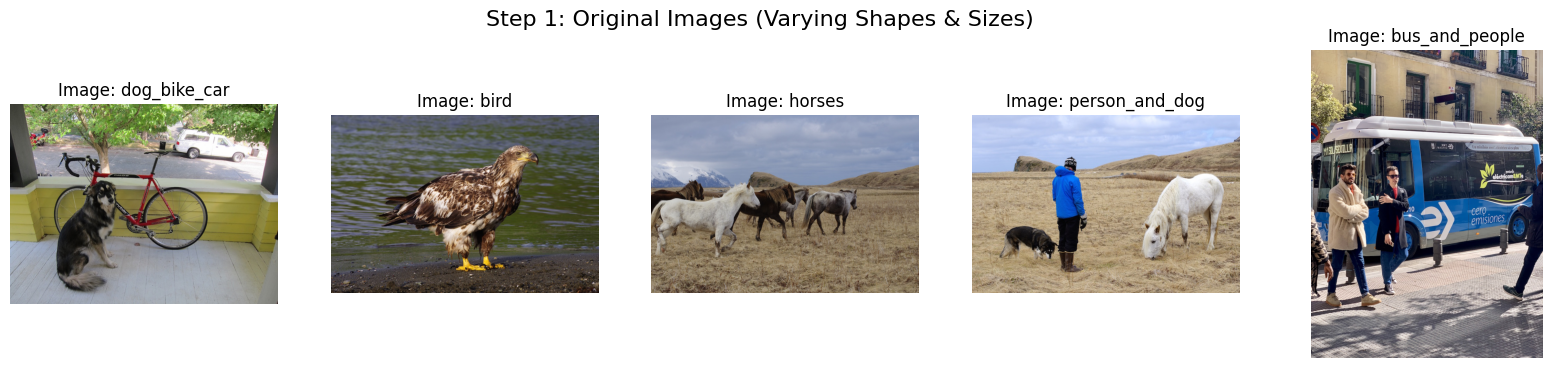

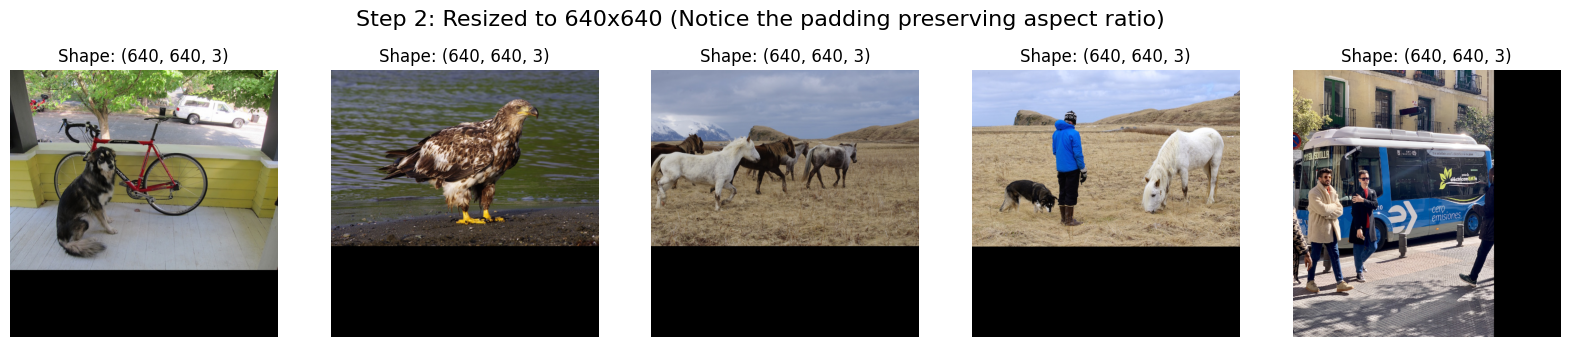

Running YOLOv8 Inference...
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step


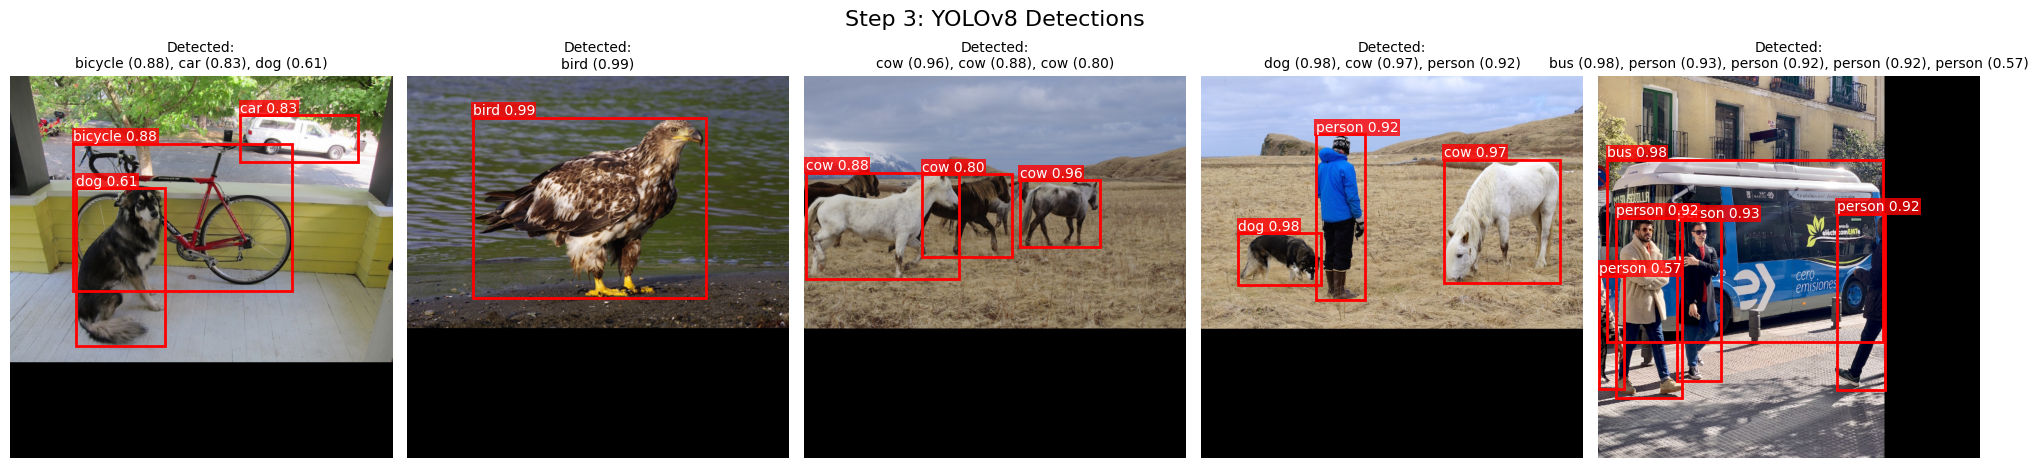

In [ ]:

# ==========================================
# 1. LOAD MODEL & MAP CLASSES
# ==========================================
print("Loading YOLOv8 Model (Pascal VOC Preset)...")
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# Pascal VOC has 20 classes. We map the integer IDs back to strings.
pascal_voc_classes = {
    0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle',
    5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow',
    10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person',
    15: 'pottedplant', 16: 'sheep', 17: 'sofa', 18: 'train', 19: 'tvmonitor'
}

# ==========================================
# 2. LOAD 5 IMAGES (Official YOLO Test Images)
# ==========================================
# Using permanent links from the original YOLO repositories
image_urls = {
    "dog_bike_car": "https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg",
    "bird": "https://raw.githubusercontent.com/pjreddie/darknet/master/data/eagle.jpg",
    "horses": "https://raw.githubusercontent.com/pjreddie/darknet/master/data/horses.jpg",
    "person_and_dog": "https://raw.githubusercontent.com/pjreddie/darknet/master/data/person.jpg",
    "bus_and_people": "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"
}

original_images = {}
for name, url in image_urls.items():
    # Adding "_v3" to the filename so it forces a fresh download
    path = tf.keras.utils.get_file(f"{name}_v3.jpg", url)
    img = tf.keras.utils.load_img(path)
    original_images[name] = np.array(img)

# --- VISUALIZE STEP 1: Original Images ---
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Step 1: Original Images (Varying Shapes & Sizes)", fontsize=16)
for ax, (name, img) in zip(axes, original_images.items()):
    ax.imshow(img)
    ax.set_title(f"Image: {name}")
    ax.axis("off")
plt.show()

# ==========================================
# 3. RESIZE IMAGES 
# ==========================================
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

resized_images = {}
for name, img in original_images.items():
    # Expand dims to simulate a batch of 1 (required by the layer)
    img_batched = np.expand_dims(img, axis=0)
    resized = inference_resizing(img_batched)
    # Remove batch dim and cast to int for clean plotting
    resized_images[name] = resized[0].numpy().astype(int)

# --- VISUALIZE STEP 2: Resized Images ---
# Notice the black padding. This stops the objects from stretching, 
# which would confuse the model!
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Step 2: Resized to 640x640 (Notice the padding preserving aspect ratio)", fontsize=16)
for ax, (name, img) in zip(axes, resized_images.items()):
    ax.imshow(img)
    ax.set_title(f"Shape: {img.shape}")
    ax.axis("off")
plt.show()

# ==========================================
# 4. RUN INFERENCE & VISUALIZE
# ==========================================
# Stack into a single batch for efficient inference
image_batch = np.stack(list(resized_images.values()))
print("Running YOLOv8 Inference...")
predictions = model.predict(image_batch)

# Extract predictions
boxes = predictions['boxes']
classes = predictions['classes']
confidences = predictions['confidence']

# --- VISUALIZE STEP 3: Bounding Boxes ---
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Step 3: YOLOv8 Detections", fontsize=16)

for i, (name, img) in enumerate(resized_images.items()):
    ax = axes[i]
    ax.imshow(img)
    ax.axis("off")
    
    img_boxes = boxes[i]
    img_classes = classes[i]
    img_confidences = confidences[i]
    
    detected = []
    
    # Loop through all possible detections for this image
    for j in range(len(img_boxes)):
        conf = img_confidences[j]
        class_id = int(img_classes[j])
        
        # Filter out padding (-1) and low confidence scores
        if conf > 0.5 and class_id != -1:
            box = img_boxes[j]
            x, y, w, h = box # Unpack xywh format
            
            label = pascal_voc_classes.get(class_id, "Unknown")
            detected.append(f"{label} ({conf:.2f})")
            
            # Draw Bounding Box
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            
            # Draw Label
            ax.text(x, y - 5, f"{label} {conf:.2f}", color='white', fontsize=10,
                    bbox=dict(facecolor='red', alpha=0.8, edgecolor='none', pad=1))
            
    ax.set_title(f"Detected:\n{', '.join(detected) if detected else 'None'}", fontsize=10)

plt.tight_layout()
plt.show()

| Image File         | Detected Correctly? (Objects & Confidence)           | Missed or Incorrectly Labeled                           |
| ------------------ | ---------------------------------------------------- | ------------------------------------------------------- |
| dog_bike_car.jpg   | Yes - bicycle (0.88), car (0.83), dog (0.61)         | None                                                    |
| bird.jpg           | Yes - bird (0.99)                                    | None                                                    |
| horses.jpg         | None                                                 | Incorrectly labeled 3 horses as cows (0.96, 0.88, 0.80) |
| person_and_dog.jpg | Yes - dog (0.98), person (0.92)                      | Incorrectly labeled a horse as a cow (0.97)             |
| bus_and_people.jpg | Yes - bus (0.98), 4x person (0.93, 0.92, 0.92, 0.57) | None                                                    |